<a href="https://colab.research.google.com/github/dlalswns0211/sparta_project_4_team16/blob/main/YJ/COLAB_DL_FD004_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ NASA C-MAPSS FD004 — 딥러닝 RUL 예측 모델링

---

**데이터셋:** NASA C-MAPSS FD004  
**목표:** 항공기 엔진 잔여 수명(RUL) 예측  
**모델:** Transformer  
**평가 지표:** RMSE, NASA Score  
**환경:** Google Colab T4 GPU  

---

## ⚠️ 주의사항
- `run_experiment_transformer(...)` 실행 코드는 주석 처리되어 있음
- 실험 실행 시 반드시 **세션 재시작 후 전체 실행** → 원하는 실험만 주석 해제
- AdamW 내부 상태(모멘텀)가 누적되므로 세션 재시작 없으면 실험 결과 오염 가능

In [ ]:
# from pyngrok import ngrok
# ngrok.kill()

# [0] 환경 설정

In [ ]:
# 설치 셀 (0번)
!pip install mlflow==2.13.0 pyngrok gunicorn -q --no-deps
import mlflow

/usr/local/lib/python3.12/dist-packages/mlflow/protos/service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service


In [ ]:
# 드라이브 마운트 먼저!
from google.colab import drive
drive.mount('/content/drive')
mlflow.set_tracking_uri("sqlite:////content/drive/MyDrive/sparta_project/mlflow.db")
!apt-get -qq install fonts-nanum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import mlflow.pytorch
import os
import json  # ← CSV 자동 저장 코드에 필요
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
print(f'PyTorch 버전: {torch.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
사용 디바이스: cuda
PyTorch 버전: 2.10.0+cu128


# [1] MLflow + ngrok

In [ ]:
# import subprocess
# import time

# subprocess.run(['pkill', '-f', 'mlflow'], capture_output=True)
# subprocess.run(['pkill', '-f', 'ngrok'], capture_output=True)
# time.sleep(3)

# process = subprocess.Popen([
#     'mlflow', 'ui',
#     '--port', '5001',
#     '--host', '0.0.0.0',
#     '--backend-store-uri', 'sqlite:////content/drive/MyDrive/sparta_project/mlflow.db'
# ], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# time.sleep(10)

# # MLflow 서버 로그 확인
# stdout, stderr = process.communicate(timeout=1) if process.poll() else (b'', b'')
# print("에러:", stderr.decode()[:300] if stderr else "없음")

# # curl로 확인
# result = subprocess.run(['curl', 'http://localhost:5001'], capture_output=True, text=True)
# print("서버 응답:", result.stdout[:100] if result.stdout else "응답 없음")
# print("에러:", result.stderr[:100])

# from pyngrok import ngrok
# from google.colab import userdata
# ngrok.kill()
# time.sleep(2)
# ngrok.set_auth_token(userdata.get("NGROK_TOKEN"))
# public_url = ngrok.connect(5001)
# print(f"MLflow UI 주소: {public_url}")

In [ ]:
# import requests
# try:
#     r = requests.get("http://localhost:5001")
#     print("mlflow 서버 정상:", r.status_code)
# except:
#     print("mlflow 서버 안 떠있음")

# print(process.stderr.read().decode())

# [2] 데이터 로드 및 3D 복원

In [ ]:
# BASE_DIR    = '/content/drive/MyDrive/sparta_project/preprocessed_FD004'
# DATA_DIR    = f'{BASE_DIR}/dl'
# WINDOW_SIZE = 30  # W-1: 20, W-2: 10으로 변경

# DL_FEATURES = ['s_2','s_3','s_4','s_7','s_8','s_9','s_10',
#                 's_11','s_12','s_13','s_14','s_15','s_17','s_20','s_21',
#                 'cluster_0','cluster_1','cluster_2','cluster_3','cluster_4','cluster_5']

# # B: 베이스라인 (cap=125 / σ=2 / win=30 / 클러스터별 MinMax)
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig2_win30_test_RUL.csv')

# def long_to_3d(df):
#     grp = df.groupby('sample_id')
#     X = np.stack([grp.get_group(i)[DL_FEATURES].values
#                   for i in range(df['sample_id'].nunique())])
#     y = df.groupby('sample_id')['RUL'].last().values
#     return X, y

# X_train, y_train = long_to_3d(subtrain_df)
# X_valid, y_valid = long_to_3d(valid_df)
# X_test,  _       = long_to_3d(test_df)
# y_test           = test_rul_df['RUL'].values

# print(f'X_train: {X_train.shape} / y_train: {y_train.shape}')
# print(f'X_valid: {X_valid.shape} / y_valid: {y_valid.shape}')
# print(f'X_test:  {X_test.shape}  / y_test:  {y_test.shape}')

In [ ]:
BASE_DIR    = '/content/drive/MyDrive/sparta_project/preprocessed_FD004_exp'
DATA_DIR    = f'{BASE_DIR}/dl'
WINDOW_SIZE = 30  # W-1: 20, W-2: 10으로 변경!!

DL_FEATURES = ['s_2','s_3','s_4','s_7','s_8','s_9','s_10',
                's_11','s_12','s_13','s_14','s_15','s_17','s_20','s_21',
                'cluster_0','cluster_1','cluster_2','cluster_3','cluster_4','cluster_5']

# # B: 베이스라인 (cap=125 / σ=2 / win=30 / 클러스터별 MinMax)
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig2_win30_test_RUL.csv')

# R-1: cap=120
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap120_sig2_win30_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap120_sig2_win30_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap120_sig2_win30_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap120_sig2_win30_test_RUL.csv')

# R-2: cap=130
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap130_sig2_win30_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap130_sig2_win30_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap130_sig2_win30_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap130_sig2_win30_test_RUL.csv')

# G-1: σ=0
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig0_win30_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig0_win30_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig0_win30_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig0_win30_test_RUL.csv')

# G-2: σ=1
subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig1_win30_dl_subtrain_long.csv')
valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig1_win30_dl_valid_long.csv')
test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig1_win30_dl_test_long.csv')
test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig1_win30_test_RUL.csv')

# G-3: σ=3
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig3_win30_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig3_win30_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig3_win30_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig3_win30_test_RUL.csv')

# N-1: Standard (WINDOW_SIZE=30 유지)
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_standard_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_standard_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win30_standard_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig2_win30_standard_test_RUL.csv')

# W-1: window=20 ( WINDOW_SIZE=20 변경 필수!)
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win20_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win20_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win20_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig2_win20_test_RUL.csv')

# W-2: window=10 ( WINDOW_SIZE=10 변경 필수!)
# subtrain_df = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win10_dl_subtrain_long.csv')
# valid_df    = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win10_dl_valid_long.csv')
# test_df     = pd.read_csv(f'{DATA_DIR}/FD004_cap125_sig2_win10_dl_test_long.csv')
# test_rul_df = pd.read_csv(f'{BASE_DIR}/FD004_cap125_sig2_win10_test_RUL.csv')

def long_to_3d(df):
    grp = df.groupby('sample_id')
    X = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df['sample_id'].nunique())])
    y = df.groupby('sample_id')['RUL'].last().values
    return X, y

X_train, y_train = long_to_3d(subtrain_df)
X_valid, y_valid = long_to_3d(valid_df)
X_test,  _       = long_to_3d(test_df)
y_test           = test_rul_df['RUL'].values

print(f'X_train: {X_train.shape} / y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape} / y_valid: {y_valid.shape}')
print(f'X_test:  {X_test.shape}  / y_test:  {y_test.shape}')

X_train: (43523, 30, 21) / y_train: (43523,)
X_valid: (10505, 30, 21) / y_valid: (10505,)
X_test:  (248, 30, 21)  / y_test:  (248,)


# [3] Dataset / DataLoader

In [ ]:
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 256  # FD001: 64 → # FD004: 256

train_dataset = RULDataset(X_train, y_train)
valid_dataset = RULDataset(X_valid, y_valid)
test_dataset  = RULDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# [4] 평가 함수

In [ ]:
def nasa_score(y_true, y_pred):
    diff = y_pred - y_true
    score = np.sum(np.where(diff < 0,
                            np.exp(-diff / 13) - 1,
                            np.exp(diff / 10) - 1))
    return score

def evaluate(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            pad_mask = (X_batch.sum(dim=-1) == 0)  # zero-padding 마스킹
            out = model(X_batch, src_key_padding_mask=pad_mask).cpu().numpy()
            preds.extend(out)
            targets.extend(y_batch.numpy())
    preds   = np.array(preds)
    targets = np.array(targets)
    rmse  = np.sqrt(np.mean((preds - targets) ** 2))
    score = nasa_score(targets, preds)
    return rmse, score, preds, targets

# [5] 학습 함수

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        pad_mask = (X_batch.sum(dim=-1) == 0)  # zero-padding 마스킹
        optimizer.zero_grad()
        pred = model(X_batch, src_key_padding_mask=pad_mask)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient Clipping
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

# [6] 시각화 함수

In [ ]:
def plot_results(exp_name, model_name, train_loss_list, val_rmse_list,
                 test_preds, test_targets):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{model_name} - {exp_name} (FD004)', fontsize=14, fontweight='bold')

    ax = axes[0]
    ax.plot(train_loss_list, label='Train Loss')
    ax.plot(val_rmse_list,   label='Val RMSE')
    ax.set_title('학습 곡선')
    ax.set_xlabel('Epoch')
    ax.legend()

    ax = axes[1]
    ax.scatter(test_targets, test_preds, alpha=0.5, s=20)
    max_val = max(test_targets.max(), test_preds.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='이상적 예측')
    ax.set_title('예측값 vs 실제값 (Test)')
    ax.set_xlabel('실제 RUL')
    ax.set_ylabel('예측 RUL')
    ax.legend()

    ax = axes[2]
    residuals = test_preds - test_targets
    ax.hist(residuals, bins=20, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', label='잔차=0')
    ax.set_title('잔차 분포 (Test)')
    ax.set_xlabel('예측 - 실제')
    ax.set_ylabel('빈도')
    ax.legend()

    plt.tight_layout()
    plt.show()

# [7] 모델 정의

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, input_size=21, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, src_key_padding_mask=None):
        x = self.input_proj(x)
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze(1)

# [8] 실험 함수


In [ ]:
EPOCHS   = 100
LR       = 1e-3
PATIENCE = 20

def run_experiment_transformer(exp_name, model_class, hidden_size=64, num_layers=2, dropout=0.2, nhead=4):
    exp_name_full = f"{model_class.__name__}_FD004"
    mlflow.set_experiment(exp_name_full)

    with mlflow.start_run(run_name=exp_name):
        mlflow.log_params({
            "model":        model_class.__name__,
            "d_model":      hidden_size,
            "num_layers":   num_layers,
            "dropout":      dropout,
            "nhead":        nhead,
            "batch_size":   BATCH_SIZE,
            "lr":           LR,
            "epochs":       EPOCHS,
            "dataset":      "FD004",
            "optimizer":    "AdamW",
            "weight_decay": 1e-4,
            "scheduler":    "ReduceLROnPlateau",
            "loss":         "HuberLoss_delta10",
            "window_size":  WINDOW_SIZE,
        })

        model = model_class(
            d_model=hidden_size,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
        criterion = nn.HuberLoss(delta=10.0)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

        best_val_rmse = float('inf')
        patience_cnt  = 0
        train_loss_list = []
        val_rmse_list   = []

        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
            val_rmse, val_score, _, _ = evaluate(model, valid_loader, device)

            scheduler.step(val_rmse)

            train_loss_list.append(train_loss)
            val_rmse_list.append(val_rmse)

            mlflow.log_metrics({
                "train_loss": train_loss,
                "val_rmse":   val_rmse,
                "val_score":  val_score,
                "lr":         optimizer.param_groups[0]['lr']
            }, step=epoch)

            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_state    = model.state_dict().copy()
                patience_cnt  = 0
            else:
                patience_cnt += 1

            if epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | train_loss: {train_loss:.4f} | val_rmse: {val_rmse:.4f} | lr: {optimizer.param_groups[0]['lr']:.6f}")

            if patience_cnt >= PATIENCE:
                print(f"Early stopping at epoch {epoch}")
                break

        model.load_state_dict(best_state)
        test_rmse, test_score, test_preds, test_targets = evaluate(model, test_loader, device)

        mlflow.log_metrics({"test_rmse": test_rmse, "test_score": test_score})
        mlflow.pytorch.log_model(model, "model")

        # ── CSV 자동 저장 ──────────────────────────────────────────
        BEST_DIR = '/content/drive/MyDrive/sparta_project/best_results'
        os.makedirs(BEST_DIR, exist_ok=True)

        MODEL_NAME = model_class.__name__
        best_meta_path = f'{BEST_DIR}/FD004_{MODEL_NAME}_best.json'

        if os.path.exists(best_meta_path):
            with open(best_meta_path) as f:
                prev_best = json.load(f)
            prev_rmse = prev_best['test_rmse']
        else:
            prev_rmse = float('inf')

        if test_rmse < prev_rmse:
            pd.DataFrame({
                'engine_id':     range(len(test_preds)),
                'actual_rul':    test_targets,
                'predicted_rul': test_preds
            }).to_csv(f'{BEST_DIR}/FD004_{MODEL_NAME}_pred.csv', index=False)

            with open(best_meta_path, 'w') as f:
                json.dump({
                    'exp_name':   exp_name,
                    'model':      MODEL_NAME,
                    'dataset':    'FD004',
                    'test_rmse':  float(test_rmse),
                    'nasa_score': float(test_score)
                }, f, indent=2)

            print(f"🏆 최고 성능 갱신! RMSE: {test_rmse:.4f} → 드라이브 저장 완료")
        else:
            print(f"📊 현재 RMSE: {test_rmse:.4f} | 기존 최고: {prev_rmse:.4f} → 저장 안함")
        # ───────────────────────────────────────────────────────────

        print(f"\n{'='*40}")
        print(f"[{exp_name}] 최종 결과")
        print(f"  Test RMSE  : {test_rmse:.4f}")
        print(f"  NASA Score : {test_score:.2f}")
        print(f"{'='*40}")

        plot_results(
            exp_name        = exp_name,
            model_name      = model_class.__name__,
            train_loss_list = train_loss_list,
            val_rmse_list   = val_rmse_list,
            test_preds      = test_preds,
            test_targets    = test_targets
        )

        return test_rmse, test_score

# [9] 실험 실행 셀

In [ ]:
# ── 전처리 실험 (AdamW, 베이스라인 파라미터 고정) ──────────
# 데이터 로드 셀에서 CSV 경로 주석 변경 + WINDOW_SIZE 확인 후 세션 재시작 → 전체 실행 → 주석 해제

# B: 베이스라인 (cap=125 / σ=2 / win=30 / 클러스터별 MinMax)
# run_experiment_transformer("B", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# R-1: cap=120
# run_experiment_transformer("R-1", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# R-2: cap=130
# run_experiment_transformer("R-2", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# G-1: σ=0
# run_experiment_transformer("G-1", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# G-2: σ=1
# run_experiment_transformer("G-2", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# G-3: σ=3
# run_experiment_transformer("G-3", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# N-1: Standard (WINDOW_SIZE=30 유지)
# run_experiment_transformer("N-1", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# W-1: window=20 ( WINDOW_SIZE=20 변경 필수!)
# run_experiment_transformer("W-1", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# W-2: window=10 ( WINDOW_SIZE=10 변경 필수!)
# run_experiment_transformer("W-2", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# [10] 실험 실행 셀
실험 순서는 무조건 B-1 → H-5 → H-6 → H-3 → H-4 → H-1 → H-2

층수가 많으면 오래 걸림

In [ ]:
# ── 하이퍼파라미터 실험 (전처리 확정 후 진행) ───────────────
# B-1: 베이스라인
# run_experiment_transformer("B-1", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# H-1: 층수 3
# run_experiment_transformer("H-1", TransformerModel, hidden_size=64, num_layers=3, dropout=0.2, nhead=4)

# H-2: 층수 4
# run_experiment_transformer("H-2", TransformerModel, hidden_size=64, num_layers=4, dropout=0.2, nhead=4)

# H-3: 은닉층 128
# run_experiment_transformer("H-3", TransformerModel, hidden_size=128, num_layers=2, dropout=0.2, nhead=4)

# H-4: 은닉층 256
# run_experiment_transformer("H-4", TransformerModel, hidden_size=256, num_layers=2, dropout=0.2, nhead=4)

# H-5: 드롭아웃 0.3
# run_experiment_transformer("H-5", TransformerModel, hidden_size=64, num_layers=2, dropout=0.3, nhead=4)

# H-6: 드롭아웃 0.5
# run_experiment_transformer("H-6", TransformerModel, hidden_size=64, num_layers=2, dropout=0.5, nhead=4)

# H-7: 헤드 수 2
# run_experiment_transformer("H-7", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=2)

# H-8: 헤드 수 8
# run_experiment_transformer("H-8", TransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=8)

# ── 추가 실험 (기본 실험 결과 확인 후 진행) ─────────────────
# Transformer: 4L-64-D0.2-H8 (4층 + 8개 헤드 조합 실험)
# → 성능 개선을 보인 4층 깊이(H-2)와 예측 안정성이 검증된 8개 헤드(H-8)의 시너지 확인을 위한 실험.
# → FD004의 다중 고장 모드에 대해 3개 층의 특징 추출과 8개 헤드의 다각도 어텐션이 결합되었을 때
#   RMSE의 추가 하락 및 NASA Score의 안정화 여부를 검증함. 모든 실험 완료 후 최종 코드 수정 예정.

# H-11: 층수 4 + 헤드수 8
# run_experiment_transformer("H-11", TransformerModel, hidden_size=64, num_layers=4, dropout=0.2, nhead=8)

# [10] 인코딩 실험 (Positional Encoding / CLS Token)

## 배경
현재 베이스라인 Transformer는 Positional Encoding이 없어서
시퀀스 내 순서 정보를 활용하지 못하고 있음.
Transformer는 원래 Self-Attention 구조상 입력 순서를 구분하지 못하기 때문에
위치 정보를 별도로 주입해줘야 시계열 패턴을 더 잘 학습할 수 있음.

## 실험 목적
위치 정보 인코딩 방식에 따른 성능 차이 확인

## 실험 종류
- P-1: Sinusoidal PE → 수식으로 고정된 위치 정보 주입 (원조 Transformer 논문 방식)
- P-2: Learnable PE → 위치 정보를 학습으로 직접 최적화
- P-3: CLS Token → 위치 정보 대신 전체 시퀀스를 요약하는 토큰 추가 (BERT 방식)

## 실험 조건
베이스라인(B-1) 기준, 인코딩 방식만 변경

# P-1: Sinusoidal Positional Encoding
# 수식으로 sin/cos 함수를 이용해 위치 정보를 고정값으로 주입
# 학습 없이 결정되며, 원조 Transformer 논문(Vaswani et al. 2017)에서 제안한 방식

변경 포인트:

input_size: 14 → 26

pe window: 30 → 20

forward에 src_key_padding_mask 추가

In [ ]:
# P-1: Sinusoidal Positional Encoding
# 수식으로 sin/cos 함수를 이용해 위치 정보를 고정값으로 주입
# 학습 없이 결정되며, 원조 Transformer 논문(Vaswani et al. 2017)에서 제안한 방식

class SinusoidalTransformerModel(nn.Module):
    def __init__(self, input_size=21, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)

        pe = torch.zeros(WINDOW_SIZE, d_model)
        position = torch.arange(0, WINDOW_SIZE).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, src_key_padding_mask=None):
        x = self.input_proj(x) + self.pe
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze(1)

# run_experiment_transformer("P-1", SinusoidalTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# P-2: Learnable Positional Encoding
# 위치 정보를 고정값이 아닌 학습 파라미터로 설정
# 데이터에 맞게 최적화되므로 도메인 특화 시퀀스에 유리할 수 있음

In [ ]:
# P-2: Learnable Positional Encoding
# 위치 정보를 고정값이 아닌 학습 파라미터로 설정
# 데이터에 맞게 최적화되므로 도메인 특화 시퀀스에 유리할 수 있음

class LearnableTransformerModel(nn.Module):
    def __init__(self, input_size=21, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pe = nn.Parameter(torch.randn(1, WINDOW_SIZE, d_model))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, src_key_padding_mask=None):
        x = self.input_proj(x) + self.pe
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.dropout(x[:, -1, :])
        return self.fc(x).squeeze(1)

# run_experiment_transformer("P-2", LearnableTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# P-3: CLS Token
# 시퀀스 앞에 학습 가능한 토큰을 추가하고 해당 토큰의 출력으로 예측
# BERT에서 제안된 방식으로, 전체 시퀀스 정보를 하나로 요약하는 역할

FD001 대비 변경 포인트:

input_size: 14 → 26

주석 (B, 31, d_model) → (B, 21, d_model) (window 20+1)

forward에 src_key_padding_mask 추가

CLS 토큰용 mask 처리 추가 (FD002 필수!)

In [ ]:
# P-3: CLS Token
# 시퀀스 앞에 학습 가능한 토큰을 추가하고 해당 토큰의 출력으로 예측
# BERT에서 제안된 방식으로, 전체 시퀀스 정보를 하나로 요약하는 역할

class CLSTransformerModel(nn.Module):
    def __init__(self, input_size=21, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x, src_key_padding_mask=None):
        x = self.input_proj(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)

        if src_key_padding_mask is not None:
            cls_mask = torch.zeros(x.size(0), 1, dtype=torch.bool, device=x.device)
            src_key_padding_mask = torch.cat([cls_mask, src_key_padding_mask], dim=1)

        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x = self.dropout(x[:, 0, :])
        return self.fc(x).squeeze(1)

# run_experiment_transformer("P-3", CLSTransformerModel, hidden_size=64, num_layers=2, dropout=0.2, nhead=4)

# 최적의 하이퍼 파라미터 + 인코딩 실험

In [ ]:
# [P-4] Transformer: 4L-64-D0.2-H4 / Learnable PE (최적 층수 + 최적 인코딩 조합)
# → 두 요소를 결합했을 때 시너지 효과가 있는지 확인하기 위한 실험
# → 층수 실험에서 최고 성능을 보인 4층 구조(H-2)와 인코딩 실험 최상위 방식인 Learnable PE(P-2)를 결합함.
# → 4개 층의 심층적 특징 추출 능력과 학습 가능한 위치 인코딩의 정교한 시계열 파악 능력이 시너지를 낼 것으로 기대.
# → 현재 최고 기록인 RMSE 27.40을 경신하고 NASA Score의 추가 하락 여부를 검증함.

# run_experiment_transformer("P-4", LearnableTransformerModel, hidden_size=64, num_layers=4, dropout=0.2, nhead=4)

# 최종 하이퍼 파라미터 + 인코딩 + 전처리 조합 실험

In [ ]:
# 하이러파라미터+인코딩 실험 완료 후 성능 결과 확인 후 코드 변경 예정
# [FINAL-COMB] 전처리 최적(Gaussian 0) + 모델 최적(4L + Learnable PE) 결합 실험
# -> [데이터 단] Gaussian 0(원본 변동성 보존) 및 Cap 125 설정의 전처리 1위 조합 활용.
# -> [모델 단] RMSE 26.32를 기록한 4층 구조(4L)와 Learnable PE(P-4) 최적 조합 적용.
# -> 가우시안 0과 1이 비등한 상황에서, 원본 특징을 최대한 살린 데이터가 4층의 깊은 표현력 및
#    학습형 위치 인코딩과 만났을 때 최종 성능(SOTA) 경신 여부를 확인하는 프로젝트 종착지 실험.

# run_experiment_transformer("F-1", LearnableTransformerModel, hidden_size=64, num_layers=4, dropout=0.2, nhead=4)

Epoch  10 | train_loss: 80.7572 | val_rmse: 17.8237 | lr: 0.001000
Epoch  20 | train_loss: 65.8933 | val_rmse: 16.8853 | lr: 0.000500
Epoch  30 | train_loss: 61.9864 | val_rmse: 16.1073 | lr: 0.000500
Epoch  40 | train_loss: 57.9612 | val_rmse: 15.6905 | lr: 0.000250
Epoch  50 | train_loss: 56.0455 | val_rmse: 15.9360 | lr: 0.000125
Epoch  60 | train_loss: 55.9903 | val_rmse: 15.9887 | lr: 0.000063
Epoch  70 | train_loss: 55.0074 | val_rmse: 15.7621 | lr: 0.000016


2026/05/04 07:32:58 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Early stopping at epoch 77


2026/05/04 07:33:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


🏆 최고 성능 갱신! RMSE: 25.7542 → 드라이브 저장 완료

[F-2] 최종 결과
  Test RMSE  : 25.7542
  NASA Score : 6211.78


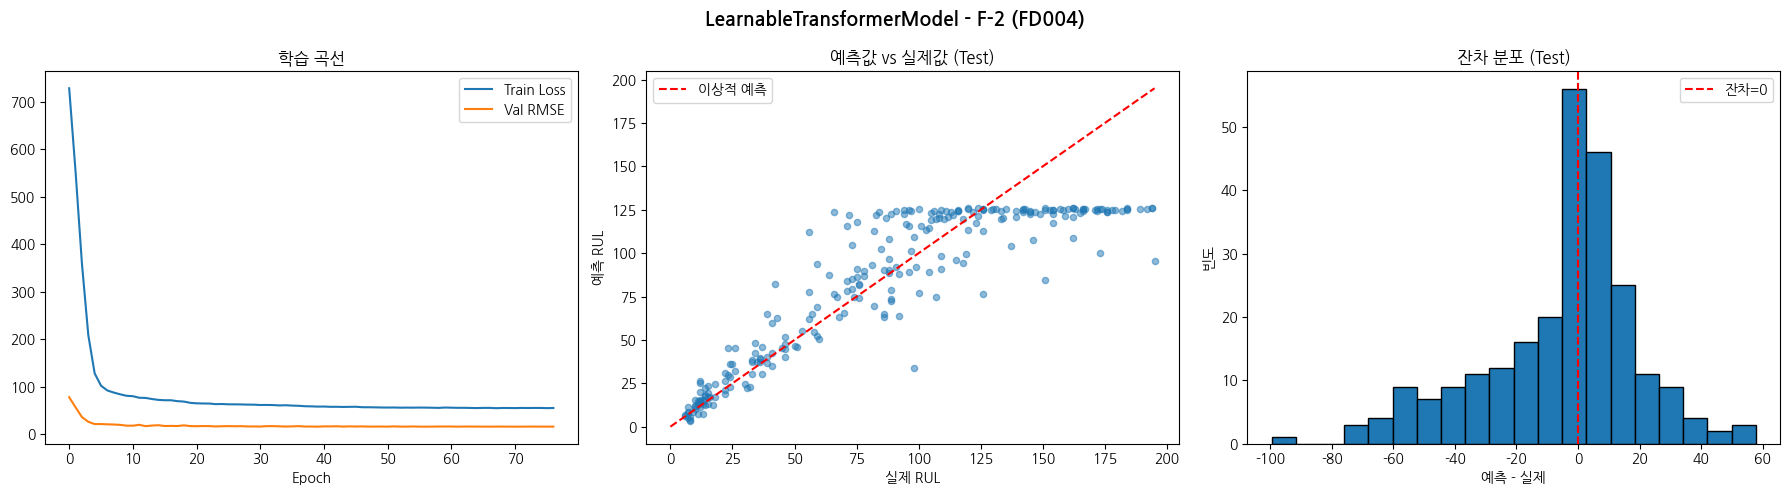

(np.float32(25.754217), np.float32(6211.7754))

In [ ]:
# 하이러파라미터+인코딩 실험 완료 후 성능 결과 확인 후 코드 변경 예정
# [FINAL-COMB] 전처리 (Gaussian 1) + 모델 최적(4L + Learnable PE) 결합 실험
# -> [데이터 단] Gaussian 1 및 Cap 125 설정의 전처리 2위 조합 활용.
# -> [모델 단] RMSE 26.32를 기록한 4층 구조(4L)와 Learnable PE(P-4) 최적 조합 적용.
# -> 가우시안 0과 1이 비등한 상황에서, 원본 특징을 최대한 살린 데이터가 4층의 깊은 표현력 및
#    학습형 위치 인코딩과 만났을 때 최종 성능(SOTA) 경신 여부를 확인하는 프로젝트 종착지 실험.

# run_experiment_transformer("F-2", LearnableTransformerModel, hidden_size=64, num_layers=4, dropout=0.2, nhead=4)